# Group 91 — DP Assignment: Autonomous Drone Rescue Using Dynamic Programming

**Part #2 — Dynamic Programming (DP)**  
**Course:** Deep Reinforcement Learning  
**Total Marks:** 5  

---

### Team Contribution Plan
| Member | Responsibility |
|--------|----------------|
| Member 1 | Section 1 — Custom Environment Design and State/Action Representation |
| Member 2 | Section 2 — Value Iteration Implementation and Convergence Analysis |
| Member 3 | Section 3 — Policy Visualisation and Trajectory Analysis |
| Member 4 | Section 4 — State-Value Analysis + Section 5 — DP Scalability Discussion |

## Header — Execution Metadata

As required by the assignment, the execution timestamp and Virtual Machine ID are printed first.

In [1]:
# ============================================================
# ASSIGNMENT HEADER — Required by assignment specification
# Prints execution timestamp and Virtual Machine ID
# ============================================================
import datetime
import platform
import sys
import os

# Capture execution metadata for submission evidence
GROUP_ID = 91                               # Team / Group number
timestamp = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
vm_id = platform.node()                     # Hostname of the virtual machine
python_version = sys.version.split()[0]     # Python version for reproducibility

print("=" * 60)
print("  Deep Reinforcement Learning — Assignment 1 (DP)")
print("=" * 60)
print(f"  Group ID         : {GROUP_ID}")
print(f"  Execution Time   : {timestamp}")
print(f"  Virtual Machine  : {vm_id}")
print(f"  Python Version   : {python_version}")
print(f"  OS               : {platform.system()} {platform.release()}")
print("=" * 60)

  Deep Reinforcement Learning — Assignment 1 (DP)
  Group ID         : 91
  Execution Time   : 2026-06-04 19:04:45
  Virtual Machine  : ANTA-GPU-Intel-01
  Python Version   : 3.10.11
  OS               : Windows 10


---
## Section 1 — Custom Drone Rescue Environment (1 Mark)

### Problem Scenario
A rescue drone is deployed in a disaster-hit city after an earthquake. The city is represented as a **5×5 grid world** (Group 91, last digit = 1, which is in range 0–4). The drone must:
- Rescue 2 stranded civilians.
- Avoid 3 danger zones (fire, unstable buildings, radiation).
- Manage battery usage (max 15 units).
- Reach the 1 charging station before battery depletes.

### Grid Configuration (Group 91)
| Parameter | Value | Derivation |
|-----------|-------|------------|
| Grid size | 5×5 | Last digit 1 ∈ [0–4] |
| Max battery | 15 | Last digit 1 is odd |
| Wind probability | 20% | Last digit 1 ∈ [0–4] |
| Max steps | 50 | 5×5 grid |
| Rescue targets | 2 | Last digit 1 ∈ [0–4] |
| Charging stations | 1 | Last digit 1 ∈ [0–4] |
| Danger zones | 3 | Last digit 1 ∈ [0–4] |
| Blocked cells | 2 | Last digit 1 ∈ [0–4] |

### State Representation
Each state is a **5-tuple**: `(row, col, battery, rescue_mask, step)`
- `row, col` : Drone position (0-indexed, top-left is (0,0))
- `battery` : Remaining battery [0, 15]
- `rescue_mask` : Integer bitmask — bit i=1 means rescue target i is still active
- `step` : Number of actions taken in this episode [0, 50]

### Action Space
5 actions: `UP`, `DOWN`, `LEFT`, `RIGHT`, `HOVER`

### Reward Structure
| Event | Reward |
|-------|--------|
| Rescue target reached | +20 |
| Enter danger zone | −10 |
| Battery exhausted | −20 |
| Reach charging station | +5 |
| Any movement (including hover) | −1 |

In [2]:
# ============================================================
# PARAMETERS (formerly from parameters.py)
# ============================================================
"""Shared assignment parameters derived from the group number."""

GROUP_NUMBER = 91
LAST_DIGIT = GROUP_NUMBER % 10

# MAB derived parameters
MAB_NUM_MEDICINES = (GROUP_NUMBER % 3) + 5
MAB_HIDDEN_PROBS = [0.4 + ((GROUP_NUMBER + i) % 6) * 0.07 for i in range(MAB_NUM_MEDICINES)]
MAB_NUM_PATIENTS = 1000

# DP derived parameters
DP_GRID_SIZE = 6 if LAST_DIGIT >= 5 else 5
DP_MAX_BATTERY = 15 if LAST_DIGIT % 2 == 1 else 10
DP_WIND_PROB = 0.30 if LAST_DIGIT >= 5 else 0.20
DP_MAX_STEPS = 75 if DP_GRID_SIZE == 6 else 50
DP_NUM_RESCUE = 2 if LAST_DIGIT <= 4 else 3
DP_NUM_CHARGERS = 1 if LAST_DIGIT <= 4 else 2
DP_NUM_DANGER = 3 if LAST_DIGIT <= 4 else 4
DP_NUM_BLOCKED = 2 if LAST_DIGIT <= 4 else 3

# Environment type indicators
MAB_ENV_NAME = "Multi-Armed Bandit"
DP_ENV_NAME = "Drone Rescue DP"

# Feature toggles
MAB_ENABLED = 1
DP_ENABLED = 1


In [3]:
# ============================================================
# ENVIRONMENT MODULE (formerly from dp/env.py)
# ============================================================
"""
Custom Drone Rescue Environment for DP Assignment (Group 91).

This module implements the DroneRescueEnv class — a fully custom grid-world
environment modelling an autonomous drone rescuing civilians in a disaster zone.
The environment is formulated as a finite Markov Decision Process (MDP).

Grid Configuration (Group 91, last digit = 1, so 5×5 grid):
  - Grid size    : 5×5
  - Max battery  : 15 (last digit odd)
  - Wind prob    : 0.20 (last digit 0–4)
  - Max steps    : 50
  - Rescue targets  : 2
  - Charging stations : 1
  - Danger zones  : 3
  - Blocked cells : 2

State Representation:
  Each state is a 5-tuple: (row, col, battery, rescue_mask, step)
    - row, col     : Drone position in the grid (0-indexed)
    - battery      : Remaining battery units [0, max_battery]
    - rescue_mask  : Integer bitmask encoding which rescue targets remain active
                     (bit i = 1 means target i has NOT yet been rescued)
    - step         : Number of actions taken so far in this episode

Cell Type Symbols:
  S = Start (top-left corner, (0,0))
  F = Free / Safe cell
  D = Danger zone (-10 reward on entry)
  R = Rescue target (+20 reward on entry, disappears after rescue)
  C = Charging station (+5 on entry; battery refilled; hover +2)
  W = Wind zone (stochastic movement)
  X = Blocked cell / obstacle (cannot enter)

Reward Structure:
  Rescue target reached  : +20
  Enter danger zone      : -10
  Battery exhausted      : -20
  Reach charging station : +5
  Regular movement       : -1
  Hover on non-charger   : -1
  Hover on charger       : +0 net (battery +2, cost -1 already applied)
"""

from typing import List, Tuple, Dict
import numpy as np
# GROUP_NUMBER defined above in parameters module


class DroneRescueEnv:
    """Grid-world MDP environment for the autonomous drone rescue problem.

    The drone starts at position (0,0) with full battery and must rescue all
    civilian targets while managing battery, avoiding danger zones, and using
    charging stations before power depletes.

    Public API (required by assignment):
        reset()          → Returns the initial state tuple.
        step(action)     → Takes an action string, returns (next_state, reward, done).
        render()         → Prints the current grid with the drone's position.
        get_transitions  → Returns the stochastic transition distribution for DP.
        valid_actions    → Returns valid actions for a given state.
        is_terminal      → Returns True if the given state is a terminal state.
        enumerate_reachable_states → BFS over all states reachable from start.
    """

    # Action set: five possible drone actions
    ACTIONS = ["UP", "DOWN", "LEFT", "RIGHT", "HOVER"]

    # Grid movement deltas for directional actions
    DELTA: Dict[str, Tuple[int, int]] = {
        "UP":    (-1,  0),
        "DOWN":  ( 1,  0),
        "LEFT":  ( 0, -1),
        "RIGHT": ( 0,  1),
    }

    # Reward values as specified in the assignment
    REWARD_RESCUE   =  20    # Reaching a rescue target
    REWARD_DANGER   = -10    # Entering a danger zone
    REWARD_BATTERY  = -20    # Battery exhausted (reaches 0)
    REWARD_CHARGING =   5    # Reaching a charging station (entry only)
    REWARD_MOVE     =  -1    # Regular movement or hover cost

    def __init__(self, group_id: int = GROUP_NUMBER):
        """Initialise the drone rescue environment for a given group ID.

        All grid parameters (size, battery, wind probability, cell placements)
        are derived deterministically from the group ID per assignment rules.

        Args:
            group_id (int): Team group number. Used to derive all environment
                            parameters. Default: GROUP_NUMBER from parameters.py.
        """
        self.group_id = group_id
        last_digit = group_id % 10

        # --- Derive environment parameters from group ID ---
        # Grid size: 5×5 if last digit 0–4, else 6×6
        self.grid_size = 6 if last_digit >= 5 else 5

        # Max battery: 15 if last digit odd, else 10
        self.max_battery = 15 if last_digit % 2 == 1 else 10

        # Wind probability: 0.30 if last digit 5–9, else 0.20
        self.wind_prob = 0.30 if last_digit >= 5 else 0.20

        # Max episode steps: 75 for 6×6 grid, 50 for 5×5 grid
        self.max_steps = 75 if self.grid_size == 6 else 50

        # Starting position is always the top-left corner
        self.start = (0, 0)

        # Build the grid and record cell positions
        self._build_grid()

        # Initialise internal simulation state (for step() / render() API)
        self._current_state = None
        self.reset()

    def _build_grid(self):
        """Construct the grid layout and record positions for each cell type.

        Grid placements are deterministic based on grid_size (group-derived).
        The 5×5 layout is used for Group 91 (last digit = 1).

        5×5 Grid Layout (Group 91):
            (0,0)S  (0,1)F  (0,2)F  (0,3)F  (0,4)D
            (1,0)F  (1,1)X  (1,2)W  (1,3)R  (1,4)F
            (2,0)F  (2,1)F  (2,2)C  (2,3)F  (2,4)X
            (3,0)F  (3,1)R  (3,2)F  (3,3)D  (3,4)W
            (4,0)F  (4,1)D  (4,2)F  (4,3)F  (4,4)F

        Symbols: S=Start, F=Free, D=Danger, R=Rescue, C=Charger, W=Wind, X=Blocked
        """
        n = self.grid_size
        self.grid = np.full((n, n), "F", dtype="<U1")
        self.grid[self.start] = "S"   # Start is always top-left

        if self.grid_size == 6:
            # 6×6 layout for groups with last digit 5–9
            self.rescue_positions   = [(1, 4), (3, 1), (4, 5)]
            self.charging_positions = [(2, 2), (5, 3)]
            self.danger_positions   = [(0, 4), (3, 3), (4, 1), (5, 0)]
            self.wind_positions     = [(1, 2), (2, 4), (4, 3)]
            self.blocked_positions  = [(1, 1), (2, 5), (4, 2)]
        else:
            # 5×5 layout for Group 91 (last digit = 1, which is in 0–4 range)
            self.rescue_positions   = [(1, 3), (3, 1)]   # 2 rescue targets
            self.charging_positions = [(2, 2)]            # 1 charging station
            self.danger_positions   = [(0, 4), (3, 3), (4, 1)]  # 3 danger zones
            self.wind_positions     = [(1, 2), (3, 4)]   # 2 wind zones
            self.blocked_positions  = [(1, 1), (2, 4)]   # 2 blocked cells

        # Write cell symbols onto the grid array
        for pos in self.rescue_positions:
            self.grid[pos] = "R"
        for pos in self.charging_positions:
            self.grid[pos] = "C"
        for pos in self.danger_positions:
            self.grid[pos] = "D"
        for pos in self.wind_positions:
            self.grid[pos] = "W"
        for pos in self.blocked_positions:
            self.grid[pos] = "X"

        # Build a lookup from rescue position → bit index for bitmask encoding
        self.rescue_index: Dict[Tuple[int, int], int] = {
            pos: idx for idx, pos in enumerate(self.rescue_positions)
        }

    # =========================================================
    # PUBLIC API
    # =========================================================

    def reset(self) -> Tuple[int, int, int, int, int]:
        """Reset the environment to the initial state for a new episode.

        Sets the drone back to position (0,0), restores full battery, marks
        all rescue targets as active (bitmask = all 1s), and resets step count.

        Returns:
            tuple: Initial state (row=0, col=0, battery=max_battery,
                   rescue_mask=all_active, step=0).
        """
        # Bitmask with all rescue targets active: bit i=1 for each target i
        initial_mask = (1 << len(self.rescue_positions)) - 1

        # Construct the initial state tuple
        self._current_state = (
            self.start[0],   # row
            self.start[1],   # col
            self.max_battery, # battery starts full
            initial_mask,    # all rescue targets active
            0,               # step counter starts at 0
        )
        return self._current_state

    def step(self, action: str) -> Tuple[Tuple[int, int, int, int, int], float, bool]:
        """Execute an action from the current state and advance one time step.

        Applies stochastic wind dynamics if the drone is on a wind cell and
        the action is a directional move. Otherwise uses deterministic dynamics.

        Args:
            action (str): One of 'UP', 'DOWN', 'LEFT', 'RIGHT', 'HOVER'.

        Returns:
            tuple:
                - next_state (tuple): New state after action.
                - reward (float): Immediate reward for this transition.
                - done (bool): True if the episode has ended.

        Raises:
            ValueError: If called in a terminal state.
        """
        if self.is_terminal(self._current_state):
            raise ValueError("Cannot call step() on a terminal state. Call reset() first.")

        # Sample a transition from the stochastic distribution
        transitions = self.get_transitions(self._current_state, action)

        # Sample one outcome according to transition probabilities
        probs    = np.array([t[0] for t in transitions])
        outcomes = list(range(len(transitions)))
        sampled  = np.random.choice(outcomes, p=probs)

        prob, next_state, reward, done = transitions[sampled]
        self._current_state = next_state
        return next_state, reward, done

    def render(self, state: Tuple[int, int, int, int, int] = None):
        """Print a text representation of the grid with the drone's current position.

        Overlays the drone marker 'D' on the grid at the drone's (row, col).
        Also prints state information (battery, rescued targets, step count).

        Args:
            state (tuple, optional): State to render. Defaults to the current
                                     internal state set by step() / reset().
        """
        if state is None:
            state = self._current_state

        row, col, battery, rescue_mask, step = state

        # Build a display grid: copy base grid, overlay drone and rescued cells
        display = self.grid.copy()

        # Mark rescued targets as free cells (they disappear after rescue)
        for pos, idx in self.rescue_index.items():
            if not (rescue_mask & (1 << idx)):   # Bit is 0 → already rescued
                display[pos] = "F"

        # Place drone marker (overrides whatever cell it's on)
        display[row, col] = "🚁"

        # Cell symbol legend
        legend = {
            "S": "Start", "F": "Free", "D": "Danger", "R": "Rescue",
            "C": "Charger", "W": "Wind", "X": "Blocked", "🚁": "Drone",
        }

        # Print the grid
        print("+" + "----+" * self.grid_size)
        for r in range(self.grid_size):
            row_str = "|"
            for c in range(self.grid_size):
                cell = display[r, c]
                if cell == "🚁":
                    row_str += " 🚁 |"
                else:
                    row_str += f"  {cell} |"
            print(row_str)
            print("+" + "----+" * self.grid_size)

        # Print state summary below the grid
        rescued_count = bin(~rescue_mask & ((1 << len(self.rescue_positions)) - 1)).count("1")
        remaining     = bin(rescue_mask).count("1")
        print(f"  Battery: {battery}/{self.max_battery}  |  "
              f"Step: {step}/{self.max_steps}  |  "
              f"Rescued: {rescued_count}/{len(self.rescue_positions)}  |  "
              f"Remaining targets: {remaining}")
        print()

    # =========================================================
    # TRANSITION DYNAMICS
    # =========================================================

    def get_transitions(
        self,
        state: Tuple[int, int, int, int, int],
        action: str,
    ) -> List[Tuple[float, Tuple[int, int, int, int, int], float, bool]]:
        """Return the full stochastic transition distribution for a (state, action) pair.

        For wind zones (W), a directional action has a probability of wind_prob
        of being redirected to a uniformly random direction (Up/Down/Left/Right).
        The intended action succeeds with probability (1 - wind_prob).

        For all other cells and for HOVER, transitions are deterministic.

        This method is the primary interface for Dynamic Programming (Value Iteration),
        as DP requires the full distribution P(s'|s,a) with associated rewards.

        Args:
            state (tuple): Current state (row, col, battery, rescue_mask, step).
            action (str): Action from ACTIONS list.

        Returns:
            List of (prob, next_state, reward, done) tuples.
            Probabilities sum to 1.0. Stochastic outcomes are merged if they
            lead to the same next_state (probabilities accumulated).
        """
        if self.is_terminal(state):
            # Terminal states: self-loop with zero reward and done=True
            return [(1.0, state, 0.0, True)]

        row, col, battery, rescue_mask, step = state

        # --- Check if the drone is currently on a wind cell ---
        on_wind_cell = (self.grid[row, col] == "W")

        if not on_wind_cell or action == "HOVER":
            # Deterministic: single outcome with probability 1.0
            next_state, reward = self._compute_next_state(state, action)
            done = self.is_terminal(next_state)
            return [(1.0, next_state, reward, done)]

        # --- Stochastic wind dynamics ---
        # The wind may redirect any directional move to a random direction.
        # Intended action: probability (1 - wind_prob)
        # Each of 4 random directions: probability wind_prob / 4

        raw_transitions = {}

        def add_outcome(prob, actual_action):
            """Helper: compute next state for an actual action and accumulate probabilities."""
            ns, rew = self._compute_next_state(state, actual_action)
            done    = self.is_terminal(ns)
            key     = ns   # Use next_state as the key for merging
            if key not in raw_transitions:
                raw_transitions[key] = [0.0, rew, done]
            raw_transitions[key][0] += prob
            # Note: rewards for the same next_state are identical (they only
            # depend on next_state), so no conflict in using the first one.

        # Intended action succeeds with (1 - wind_prob)
        add_outcome(1.0 - self.wind_prob, action)

        # Wind disturbance: redirect to each of 4 directions uniformly
        random_prob = self.wind_prob / 4.0
        for random_action in ["UP", "DOWN", "LEFT", "RIGHT"]:
            add_outcome(random_prob, random_action)

        # Build final list of (prob, next_state, reward, done) tuples
        return [(data[0], ns, data[1], data[2]) for ns, data in raw_transitions.items()]

    def _compute_next_state(
        self,
        state: Tuple[int, int, int, int, int],
        action: str,
    ) -> Tuple[Tuple[int, int, int, int, int], float]:
        """Compute the deterministic next state and reward for a (state, action) pair.

        Handles all environment dynamics:
          - Battery consumption (every action costs 1 unit).
          - Hover on charging station: battery += 2 (bonus, net cost = -1 already applied).
          - Entry into charging station: battery refills to max.
          - Rescue target collection: target disappears, rescue_mask updated.
          - Blocked cell collision: drone stays, battery still consumed.
          - Boundary collision: drone stays, battery still consumed.
          - Danger zone penalty.
          - Battery exhaustion penalty.

        Args:
            state (tuple): Current state (row, col, battery, rescue_mask, step).
            action (str): Action string from ACTIONS.

        Returns:
            tuple: (next_state, reward)
        """
        row, col, battery, rescue_mask, step = state

        # Every action (move or hover) consumes 1 battery unit
        battery -= 1

        if action == "HOVER":
            # Hovering: drone stays in place
            new_row, new_col = row, col
            if self.grid[row, col] == "C":
                # On a charging station: hovering adds +2 battery (capped at max)
                battery = min(self.max_battery, battery + 2)
        else:
            # Directional move: compute intended new position
            new_row, new_col = self._move(row, col, action)

            # If landing on a charging station: refill battery to maximum
            if (new_row, new_col) in self.charging_positions:
                battery = self.max_battery

        # Update rescue bitmask: if drone lands on an active rescue target, collect it
        new_mask = rescue_mask
        if self._is_rescue_active(new_row, new_col, rescue_mask):
            # Clear the bit for this rescue target (mark as rescued)
            bit = 1 << self.rescue_index[(new_row, new_col)]
            new_mask = rescue_mask & ~bit

        # --- Compute reward for this transition ---
        reward = self.REWARD_MOVE   # Base cost: -1 for every action

        # Danger zone: additional -10 penalty (does NOT terminate the episode)
        if self.grid[new_row, new_col] == "D":
            reward += self.REWARD_DANGER

        # Charging station entry reward (only on entry, not hovering in place)
        if (new_row, new_col) in self.charging_positions and (new_row, new_col) != (row, col):
            reward += self.REWARD_CHARGING

        # Rescue target collected: +20 reward
        if self._is_rescue_active(new_row, new_col, rescue_mask):
            reward += self.REWARD_RESCUE

        # Battery exhausted: additional -20 penalty and episode ends
        battery = max(battery, 0)   # Clamp battery at 0 (no negative battery)
        if battery <= 0:
            reward += self.REWARD_BATTERY

        new_state = (new_row, new_col, battery, new_mask, step + 1)
        return new_state, reward

    def _move(self, row: int, col: int, action: str) -> Tuple[int, int]:
        """Apply a directional action and return the resulting grid position.

        If the move would leave the grid boundary or enter a blocked cell (X),
        the drone remains in its current position (bounce-back behaviour).

        Args:
            row (int): Current row.
            col (int): Current column.
            action (str): Directional action ('UP', 'DOWN', 'LEFT', 'RIGHT').

        Returns:
            tuple: (new_row, new_col) after applying the action.
        """
        dr, dc = self.DELTA[action]
        new_row, new_col = row + dr, col + dc

        # Check grid boundary
        if not (0 <= new_row < self.grid_size and 0 <= new_col < self.grid_size):
            return row, col   # Bounce back to current position

        # Check for blocked cell obstacle
        if self.grid[new_row, new_col] == "X":
            return row, col   # Bounce back; action still costs 1 battery unit

        return new_row, new_col

    def _is_rescue_active(
        self, row: int, col: int, rescue_mask: int
    ) -> bool:
        """Check if a rescue target at position (row, col) is still active.

        Uses bitmask encoding: bit i=1 means rescue target i has NOT been rescued.

        Args:
            row (int): Grid row to check.
            col (int): Grid column to check.
            rescue_mask (int): Current rescue bitmask.

        Returns:
            bool: True if there is an active (unrescued) target at (row, col).
        """
        if (row, col) not in self.rescue_index:
            return False
        bit = 1 << self.rescue_index[(row, col)]
        return (rescue_mask & bit) != 0

    # =========================================================
    # STATE SPACE UTILITIES
    # =========================================================

    def is_terminal(self, state: Tuple[int, int, int, int, int]) -> bool:
        """Determine if a state is terminal (episode ends).

        An episode terminates when any of the following occur:
          1. Battery reaches 0 (drone is stranded).
          2. All rescue targets have been rescued (rescue_mask == 0).
          3. Maximum step limit is exceeded.

        Args:
            state (tuple): State to evaluate.

        Returns:
            bool: True if the episode has terminated.
        """
        _, _, battery, rescue_mask, step = state
        all_rescued = (rescue_mask == 0)   # All bits cleared → all targets saved
        return battery <= 0 or all_rescued or step >= self.max_steps

    def valid_actions(self, state: Tuple[int, int, int, int, int]) -> List[str]:
        """Return the list of valid actions available from a given state.

        All 5 actions are always valid from non-terminal states. The environment
        handles boundary and blocked-cell collisions internally (drone stays in
        place), so no actions need to be filtered at this level.

        Args:
            state (tuple): State to query.

        Returns:
            List[str]: All ACTIONS if state is non-terminal, else [].
        """
        if self.is_terminal(state):
            return []   # No actions available in terminal states
        return self.ACTIONS.copy()

    def enumerate_reachable_states(self) -> List[Tuple[int, int, int, int, int]]:
        """Enumerate all states reachable from the initial state via BFS.

        Uses stochastic transitions (get_transitions) to ensure that wind-zone
        states are properly explored. This guarantees the DP algorithm has
        complete coverage of the state space.

        Returns:
            List[tuple]: All reachable states as (row, col, battery, mask, step).
        """
        from collections import deque

        # Start state: top-left, full battery, all targets active, step=0
        start_mask  = (1 << len(self.rescue_positions)) - 1
        start_state = (self.start[0], self.start[1], self.max_battery, start_mask, 0)

        queue   = deque([start_state])
        visited = {start_state}

        while queue:
            state = queue.popleft()
            if self.is_terminal(state):
                continue   # Do not expand terminal states

            for action in self.valid_actions(state):
                # Use get_transitions to include stochastic wind outcomes
                for _prob, next_state, _reward, _done in self.get_transitions(state, action):
                    if next_state not in visited:
                        visited.add(next_state)
                        queue.append(next_state)

        return list(visited)

    def state_description(self) -> str:
        """Return a human-readable description of the state representation.

        Returns:
            str: Multi-line explanation of each component of the state tuple.
        """
        n_targets = len(self.rescue_positions)
        n_states_approx = (
            self.grid_size ** 2
            * (self.max_battery + 1)
            * (2 ** n_targets)
            * (self.max_steps + 1)
        )
        return (
            f"State = (row, col, battery, rescue_mask, step)\n"
            f"  row         : Drone row position [0, {self.grid_size-1}]\n"
            f"  col         : Drone column position [0, {self.grid_size-1}]\n"
            f"  battery     : Remaining battery [0, {self.max_battery}]\n"
            f"  rescue_mask : Bitmask — {n_targets} bits, one per rescue target\n"
            f"                bit i=1 → target i still active, bit i=0 → rescued\n"
            f"                Range: [0, {(1 << n_targets) - 1}]\n"
            f"  step        : Actions taken so far [0, {self.max_steps}]\n"
            f"\n"
            f"  Theoretical upper bound on states:\n"
            f"    {self.grid_size}×{self.grid_size} × {self.max_battery+1} battery levels "
            f"× {2**n_targets} rescue masks × {self.max_steps+1} steps\n"
            f"    = {n_states_approx:,} states (most are unreachable)\n"
        )


In [4]:
# ============================================================
# MDP MODULE (formerly from dp/mdp.py)
# ============================================================
"""
Dynamic Programming Solution for Drone Rescue Environment (Group 91).

This module implements Value Iteration to compute the optimal value function
V*(s) and optimal policy π*(s) for the DroneRescueEnv MDP.

Value Iteration Algorithm:
  Repeatedly apply the Bellman optimality update until convergence:

    V(s) ← max_a Σ_{s'} P(s'|s,a) × [R(s,a,s') + γ × V(s')]

  Where:
    - P(s'|s,a) : Transition probability (from get_transitions)
    - R(s,a,s') : Immediate reward
    - γ          : Discount factor (default 1.0 for undiscounted)
    - θ          : Convergence threshold (1e-3 as required by assignment)

Convergence is declared when the maximum change in V(s) across all states
in one iteration falls below θ = 10⁻³.
"""

import time
from typing import Dict, List, Tuple
import numpy as np
# DroneRescueEnv class defined above in env module


def value_iteration(
    env: DroneRescueEnv,
    reachable_states: List[Tuple[int, int, int, int, int]],
    theta: float = 1e-3,
    gamma: float = 1.0,
    max_iters: int = 2000,
) -> Tuple[np.ndarray, Dict[Tuple[int, int, int, int, int], str], int, float, List[float]]:
    """Compute the optimal value function and policy using Value Iteration.

    Implements the standard Value Iteration algorithm (Bellman optimality
    operator applied until convergence) over the set of reachable states.

    Stochastic transitions from wind zones are handled correctly via
    env.get_transitions(state, action), which returns the full distribution
    P(s'|s,a) with associated rewards.

    Stopping criterion:
        Converges when max_s |V_new(s) - V_old(s)| < θ = 10⁻³.

    Args:
        env (DroneRescueEnv): The drone rescue environment instance.
        reachable_states (List[tuple]): All reachable states from BFS enumeration.
        theta (float): Convergence threshold. Default 1e-3 (assignment required).
        gamma (float): Discount factor γ ∈ (0, 1]. Default 1.0 (undiscounted).
        max_iters (int): Maximum iterations before forced stopping.

    Returns:
        tuple:
            - value (np.ndarray): Optimal value V*(s) for each reachable state.
                                   Indexed by state_to_index mapping.
            - policy (Dict): Maps each non-terminal state → optimal action string.
            - iterations (int): Number of iterations until convergence.
            - final_delta (float): Max |V_new - V_old| at the last iteration.
            - delta_history (List[float]): Per-iteration delta for convergence plot.
    """
    # Build index mapping: state tuple → array position
    state_to_index = {state: idx for idx, state in enumerate(reachable_states)}

    # Initialise value function to zero for all states
    value = np.zeros(len(reachable_states), dtype=float)

    policy = {}         # Optimal action per non-terminal state
    delta_history = []  # Track convergence for plotting

    for iteration in range(1, max_iters + 1):
        delta = 0.0   # Maximum value change this iteration

        # --- Bellman optimality update for every non-terminal state ---
        for state in reachable_states:
            if env.is_terminal(state):
                # Terminal states have zero value (no future reward possible)
                continue

            best_value  = -np.inf
            best_action = env.ACTIONS[0]   # Default fallback

            # --- Evaluate all valid actions using Bellman expectation ---
            for action in env.valid_actions(state):
                # Get full stochastic transition distribution for (state, action)
                transitions = env.get_transitions(state, action)

                # Compute expected value: Σ_s' P(s'|s,a) × [R(s,a,s') + γ × V(s')]
                action_value = 0.0
                for prob, next_state, reward, done in transitions:
                    # Get value of next state (0 if terminal or not indexed)
                    next_idx = state_to_index.get(next_state, None)
                    if next_idx is not None:
                        next_value = value[next_idx]
                    else:
                        next_value = 0.0   # Unvisited states treated as zero value
                    # Bellman update contribution from this transition outcome
                    action_value += prob * (reward + gamma * next_value)

                # Track the best action value
                if action_value > best_value:
                    best_value  = action_value
                    best_action = action

            # Compute delta: maximum change in value function
            idx = state_to_index[state]
            delta = max(delta, abs(value[idx] - best_value))

            # Update value and policy for this state
            value[idx]    = best_value
            policy[state] = best_action

        # Record delta for convergence plot
        delta_history.append(delta)

        # --- Check convergence criterion ---
        if delta < theta:
            return value, policy, iteration, delta, delta_history

    # If max iterations reached without convergence, return best result so far
    return value, policy, max_iters, delta, delta_history


def extract_greedy_trajectory(
    env: DroneRescueEnv,
    policy: Dict[Tuple[int, int, int, int, int], str],
    max_steps: int = None,
) -> List[Tuple[Tuple[int, int, int, int, int], str, float]]:
    """Simulate a greedy trajectory by following the optimal policy deterministically.

    Useful for visualising the learned policy as a sequence of states, actions,
    and rewards from the start state.

    Args:
        env (DroneRescueEnv): The environment (used for transitions).
        policy (Dict): Optimal policy mapping state → action.
        max_steps (int, optional): Maximum steps to simulate.
                                    Defaults to env.max_steps.

    Returns:
        List of (state, action, reward) triples for each step taken.
    """
    if max_steps is None:
        max_steps = env.max_steps

    trajectory = []
    state = env.reset()   # Start from the initial state

    for _ in range(max_steps):
        if env.is_terminal(state):
            break   # Stop when the episode ends

        # Choose action from optimal policy; default to HOVER if state not in policy
        action = policy.get(state, "HOVER")

        # Step deterministically (use the most probable outcome for visualization)
        transitions = env.get_transitions(state, action)
        # Pick the highest-probability transition
        best_t = max(transitions, key=lambda t: t[0])
        _, next_state, reward, done = best_t

        trajectory.append((state, action, reward))
        state = next_state

    # Append final state with no action
    trajectory.append((state, None, 0.0))
    return trajectory


In [5]:
# ============================================================
# VISUALIZATION MODULE (formerly from dp/visualization.py)
# ============================================================
"""
Visualization Utilities for DP Drone Rescue Assignment (Group 91).

This module provides richly-styled plotting functions for:
  1. plot_grid_layout     : Colored grid showing all cell types.
  2. plot_policy          : Policy arrows overlaid on the color-coded grid.
  3. plot_value_heatmap   : State-value heatmap for a fixed battery/mask slice.
  4. plot_multi_heatmaps  : Side-by-side heatmaps varying battery level.
  5. plot_trajectory      : Animate/display the greedy policy trajectory on the grid.

Color scheme for cell types:
  S (Start)    : Light blue
  F (Free)     : White / light grey
  D (Danger)   : Red
  R (Rescue)   : Green
  C (Charging) : Blue
  W (Wind)     : Yellow
  X (Blocked)  : Dark grey
"""

from typing import Dict, List, Optional, Tuple
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
# DroneRescueEnv class defined above in env module


# Cell type to background colour mapping
CELL_COLORS = {
    "S": "#AED6F1",   # Light blue — Start
    "F": "#F8F9FA",   # Near-white — Free/Safe
    "D": "#E74C3C",   # Red — Danger
    "R": "#27AE60",   # Green — Rescue
    "C": "#2980B9",   # Blue — Charging
    "W": "#F39C12",   # Orange/Yellow — Wind
    "X": "#717D7E",   # Dark grey — Blocked
}

# Arrow symbols for policy directions
DIRECTION_SYMBOLS = {
    "UP":    "↑",
    "DOWN":  "↓",
    "LEFT":  "←",
    "RIGHT": "→",
    "HOVER": "●",
}


def _draw_colored_grid(ax, env: DroneRescueEnv, rescue_mask: int = None):
    """Draw the color-coded grid background on a matplotlib Axes object.

    Fills each cell with a background colour matching its type, and adds the
    cell-type symbol as a text overlay.

    Args:
        ax: Matplotlib Axes to draw on.
        env (DroneRescueEnv): Environment containing grid layout information.
        rescue_mask (int, optional): Current rescue bitmask to show which
                                     targets have been collected (shown as 'F').
    """
    n = env.grid_size

    for r in range(n):
        for c in range(n):
            # Determine cell type, accounting for rescued targets
            cell_type = env.grid[r, c]
            if rescue_mask is not None and cell_type == "R":
                pos = (r, c)
                if pos in env.rescue_index:
                    bit = 1 << env.rescue_index[pos]
                    if not (rescue_mask & bit):
                        cell_type = "F"   # Target has been rescued → free cell

            # Fill cell with type-specific background colour
            color = CELL_COLORS.get(cell_type, "#FFFFFF")
            rect = plt.Rectangle(
                (c - 0.5, r - 0.5), 1, 1,
                facecolor=color, edgecolor="#BBBBBB", linewidth=0.8
            )
            ax.add_patch(rect)

            # Add cell type label in the corner (small, light text)
            ax.text(
                c - 0.38, r - 0.38, cell_type,
                ha="left", va="top", fontsize=7,
                color="#444444", alpha=0.7
            )


def plot_grid_layout(env: DroneRescueEnv):
    """Plot the static grid layout showing all cell types with a color legend.

    Draws the full grid with colored backgrounds, cell-type symbols, and a
    legend explaining each color. Includes grid coordinates on the axes.

    Args:
        env (DroneRescueEnv): Environment to visualise.
    """
    n = env.grid_size
    fig, ax = plt.subplots(figsize=(7, 7))

    # Draw the coloured grid
    _draw_colored_grid(ax, env)

    # Add coordinate labels in each cell
    for r in range(n):
        for c in range(n):
            ax.text(c, r, f"({r},{c})", ha="center", va="center",
                    fontsize=8, color="#222222", fontweight="bold")

    # Axis formatting
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)   # Invert y-axis so (0,0) is top-left
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"Col {i}" for i in range(n)], fontsize=9)
    ax.set_yticklabels([f"Row {i}" for i in range(n)], fontsize=9)
    ax.set_title(
        f"Drone Rescue Grid Layout — Group 91 ({n}×{n})\n"
        f"Battery: {env.max_battery} | Wind Prob: {env.wind_prob:.0%} | Max Steps: {env.max_steps}",
        fontsize=12, fontweight="bold", pad=12
    )

    # Legend patches
    legend_patches = [
        mpatches.Patch(color=CELL_COLORS[t], label=f"{t} — {name}")
        for t, name in [("S","Start"), ("F","Free/Safe"), ("D","Danger"),
                        ("R","Rescue"), ("C","Charging"), ("W","Wind"), ("X","Blocked")]
    ]
    ax.legend(handles=legend_patches, loc="upper right", bbox_to_anchor=(1.32, 1.0),
              fontsize=9, framealpha=0.95)

    plt.tight_layout()
    plt.show()


def plot_policy(
    env: DroneRescueEnv,
    policy: Dict,
    battery: int,
    rescue_mask: int,
    step: int = 0,
    title: str = None,
    ax=None,
):
    """Plot the greedy policy arrows overlaid on the colour-coded grid.

    For each non-terminal, non-blocked cell, draws the optimal action as a
    directional arrow (or hover dot). Blocked and terminal cells are shown
    with their base cell colour but no arrow.

    Args:
        env (DroneRescueEnv): Environment with grid layout.
        policy (Dict): Optimal policy mapping state → action string.
        battery (int): Battery level to query the policy for (fixed slice).
        rescue_mask (int): Rescue bitmask to query the policy for.
        step (int): Step count for state lookup. Default 0.
        title (str, optional): Custom plot title. Auto-generated if None.
        ax: Optional existing Axes to draw on. Creates a new figure if None.
    """
    n = env.grid_size
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 7))

    # Draw color-coded grid background
    _draw_colored_grid(ax, env, rescue_mask=rescue_mask)

    # Overlay policy arrows for each cell
    for r in range(n):
        for c in range(n):
            state = (r, c, battery, rescue_mask, step)
            if state in policy:
                action = policy[state]
                symbol = DIRECTION_SYMBOLS.get(action, "?")
                ax.text(
                    c, r, symbol,
                    ha="center", va="center",
                    fontsize=22, fontweight="bold",
                    color="#1A1A2E",
                )
            elif env.grid[r, c] == "X":
                # Blocked cell: show X
                ax.text(c, r, "✕", ha="center", va="center",
                        fontsize=20, color="#FFFFFF")

    # Axis formatting
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"C{i}" for i in range(n)], fontsize=9)
    ax.set_yticklabels([f"R{i}" for i in range(n)], fontsize=9)

    if title is None:
        rescued_n = bin(~rescue_mask & ((1 << len(env.rescue_positions)) - 1)).count("1")
        title = (f"Optimal Policy — Battery={battery}, "
                 f"Rescued={rescued_n}/{len(env.rescue_positions)}")
    ax.set_title(title, fontsize=11, fontweight="bold")

    if standalone:
        plt.tight_layout()
        plt.show()


def plot_value_heatmap(
    env: DroneRescueEnv,
    value: np.ndarray,
    state_to_index: Dict,
    battery: int,
    rescue_mask: int,
    step: int = 0,
    title: str = None,
    ax=None,
):
    """Plot a heatmap of V*(s) for a fixed battery level and rescue mask.

    Produces a colour-gradient heatmap where brighter colours indicate
    higher state values. Numeric values are annotated in each cell.
    Blocked and unreachable cells are shown in grey.

    Args:
        env (DroneRescueEnv): Environment with grid layout.
        value (np.ndarray): Optimal value array (indexed by state_to_index).
        state_to_index (Dict): Maps state tuple → index into value array.
        battery (int): Fixed battery level for the slice.
        rescue_mask (int): Fixed rescue mask for the slice.
        step (int): Fixed step for the slice. Default 0.
        title (str, optional): Plot title. Auto-generated if None.
        ax: Optional existing Axes. Creates new figure if None.
    """
    n = env.grid_size
    heatmap = np.full((n, n), np.nan, dtype=float)

    # Populate the heatmap grid with V*(s) values for this slice
    for r in range(n):
        for c in range(n):
            if env.grid[r, c] == "X":
                continue   # Skip blocked cells
            state = (r, c, battery, rescue_mask, step)
            if state in state_to_index:
                heatmap[r, c] = value[state_to_index[state]]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 7))

    # Draw the heatmap image
    im = ax.imshow(
        heatmap, cmap="RdYlGn", origin="upper",
        vmin=np.nanmin(heatmap) if not np.all(np.isnan(heatmap)) else -1,
        vmax=np.nanmax(heatmap) if not np.all(np.isnan(heatmap)) else 1,
    )

    # Annotate each cell with its V* value and cell type
    for r in range(n):
        for c in range(n):
            cell = env.grid[r, c]
            if np.isnan(heatmap[r, c]):
                # Blocked or unreachable: grey overlay
                ax.add_patch(plt.Rectangle(
                    (c - 0.5, r - 0.5), 1, 1,
                    facecolor="#888888", edgecolor="black", linewidth=0.5
                ))
                ax.text(c, r, cell, ha="center", va="center",
                        fontsize=12, color="white")
            else:
                # Annotate with V* value
                ax.text(c, r, f"{heatmap[r, c]:.1f}", ha="center", va="center",
                        fontsize=10, fontweight="bold", color="#1A1A1A")

    if standalone:
        plt.colorbar(im, ax=ax, label="State Value V*(s)")

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"C{i}" for i in range(n)], fontsize=9)
    ax.set_yticklabels([f"R{i}" for i in range(n)], fontsize=9)

    if title is None:
        title = f"V*(s) Heatmap — Battery={battery}, Mask={bin(rescue_mask)}"
    ax.set_title(title, fontsize=11, fontweight="bold")

    if standalone:
        plt.tight_layout()
        plt.show()

    return im


def plot_multi_heatmaps(
    env: DroneRescueEnv,
    value: np.ndarray,
    state_to_index: Dict,
    rescue_mask: int,
    battery_levels: List[int] = None,
):
    """Plot side-by-side value heatmaps for multiple battery levels.

    Allows comparison of how state values change as battery depletes.
    Each sub-plot shows V*(s) for a different battery level, with the
    same rescue mask.

    Args:
        env (DroneRescueEnv): Environment with grid layout.
        value (np.ndarray): Optimal value array.
        state_to_index (Dict): State → index mapping.
        rescue_mask (int): Fixed rescue bitmask for all sub-plots.
        battery_levels (List[int], optional): Battery levels to show.
                                              Defaults to [5, 10, max].
    """
    if battery_levels is None:
        # Sample low, medium, and full battery levels
        battery_levels = [5, 10, env.max_battery]

    n_plots = len(battery_levels)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 7))
    if n_plots == 1:
        axes = [axes]

    fig.suptitle(
        f"State-Value Analysis: V*(s) vs Battery Level (Group 91)\n"
        f"Rescue Mask = {bin(rescue_mask)} ({bin(rescue_mask).count('1')} targets remaining)",
        fontsize=13, fontweight="bold"
    )

    ims = []
    for ax, battery in zip(axes, battery_levels):
        im = plot_value_heatmap(
            env, value, state_to_index,
            battery=battery,
            rescue_mask=rescue_mask,
            title=f"Battery = {battery}",
            ax=ax,
        )
        ims.append(im)

    # Shared colorbar
    fig.colorbar(ims[-1], ax=axes, label="State Value V*(s)", shrink=0.6)
    plt.tight_layout()
    plt.show()


def plot_trajectory(
    env: DroneRescueEnv,
    trajectory: List[Tuple],
    title: str = "Greedy Policy Trajectory",
):
    """Visualise the greedy trajectory as a sequence of numbered steps on the grid.

    Draws the drone's path as a directed line with numbered waypoints.
    Each step is annotated with the action taken and the step number.

    Args:
        env (DroneRescueEnv): Environment with grid layout.
        trajectory (List[tuple]): Output of extract_greedy_trajectory().
                                   Each element: (state, action, reward).
        title (str): Plot title.
    """
    n = env.grid_size
    fig, ax = plt.subplots(figsize=(8, 8))

    # Draw the base grid (using initial rescue_mask from the first state)
    initial_mask = trajectory[0][0][3] if trajectory else (1 << len(env.rescue_positions)) - 1
    _draw_colored_grid(ax, env, rescue_mask=initial_mask)

    # Extract path positions
    positions = [step[0][:2] for step in trajectory]   # (row, col) sequence

    # Draw the trajectory as connected arrows
    for i in range(len(positions) - 1):
        r1, c1 = positions[i]
        r2, c2 = positions[i + 1]
        ax.annotate(
            "",
            xy=(c2, r2), xytext=(c1, r1),
            arrowprops=dict(
                arrowstyle="->",
                color="#1A1A2E",
                lw=2.0,
                connectionstyle="arc3,rad=0.0"
            )
        )

    # Number each waypoint
    for i, (r, c) in enumerate(positions):
        ax.text(
            c + 0.15, r - 0.15, str(i),
            ha="left", va="top",
            fontsize=8, color="#C0392B", fontweight="bold"
        )

    # Mark start (S) and end
    if positions:
        rs, cs = positions[0]
        ax.plot(cs, rs, "go", markersize=12, label="Start", zorder=5)
        re, ce = positions[-1]
        ax.plot(ce, re, "r*", markersize=14, label="End", zorder=5)

    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(n - 0.5, -0.5)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels([f"C{i}" for i in range(n)], fontsize=9)
    ax.set_yticklabels([f"R{i}" for i in range(n)], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12)
    ax.legend(loc="lower right", fontsize=9)

    # Compute total reward from trajectory
    total_reward = sum(step[2] for step in trajectory)
    ax.text(
        0.02, 0.02,
        f"Steps: {len(trajectory)-1} | Total Reward: {total_reward:.1f}",
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
    )

    plt.tight_layout()
    plt.show()


def plot_policy_multi_slice(
    env: DroneRescueEnv,
    policy: Dict,
    rescue_mask: int,
    battery_levels: List[int] = None,
):
    """Plot policy visualisations for multiple battery levels side by side.

    Useful for showing how the optimal policy changes as battery depletes —
    for example, the drone may prefer charging stations at low battery.

    Args:
        env (DroneRescueEnv): Environment with grid layout.
        policy (Dict): Optimal policy mapping state → action.
        rescue_mask (int): Rescue bitmask to fix for all slices.
        battery_levels (List[int], optional): Battery levels to show.
    """
    if battery_levels is None:
        battery_levels = [5, 10, env.max_battery]

    n_plots = len(battery_levels)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 7))
    if n_plots == 1:
        axes = [axes]

    fig.suptitle(
        "Optimal Policy π*(s) — Policy Varies with Battery Level (Group 91)",
        fontsize=13, fontweight="bold"
    )

    for ax, battery in zip(axes, battery_levels):
        plot_policy(
            env, policy, battery=battery,
            rescue_mask=rescue_mask,
            title=f"Battery = {battery}",
            ax=ax
        )

    plt.tight_layout()
    plt.show()


In [6]:
# ============================================================
# ANALYSIS MODULE (formerly from dp/analysis.py)
# ============================================================
"""
Analysis Helpers for DP Drone Rescue Assignment (Group 91).

This module provides functions for summarising and plotting DP results:
  - summarize_dp_results   : Print formatted convergence and runtime summary.
  - plot_convergence       : Plot delta (max value change) vs iteration number.
  - print_scalability_discussion : Print the curse of dimensionality analysis.
"""

from typing import Dict, List
import numpy as np
import matplotlib.pyplot as plt


def summarize_dp_results(metadata: Dict) -> str:
    """Build and return a formatted summary of Dynamic Programming results.

    Formats key convergence metrics into a readable string block for display
    in the Jupyter notebook output.

    Args:
        metadata (Dict): Results dictionary with keys:
            'iterations' : Number of VI iterations until convergence.
            'runtime'    : Wall-clock time in seconds.
            'delta'      : Final max |V_new - V_old| at convergence.
            'start_value': V*(start state) — expected return from the start.
            'n_states'   : Total number of reachable states explored.

    Returns:
        str: Formatted multi-line summary string.
    """
    sep = "=" * 60
    lines = [
        sep,
        "  Dynamic Programming — Value Iteration Results (Group 91)",
        sep,
        f"  Convergence iterations  : {metadata.get('iterations', 'N/A')}",
        f"  Runtime                 : {metadata.get('runtime', 0.0):.4f} seconds",
        f"  Final delta (max ΔV)    : {metadata.get('delta', 0.0):.2e}",
        f"  Convergence threshold θ : 1e-3",
        f"  Discount factor γ       : 1.0 (undiscounted)",
        f"  Reachable states        : {metadata.get('n_states', 'N/A'):,}",
        f"  V*(start state)         : {metadata.get('start_value', 0.0):.4f}",
        sep,
    ]
    return "\n".join(lines)


def plot_convergence(
    delta_history: List[float],
    theta: float = 1e-3,
    title: str = "Value Iteration Convergence — Group 91",
):
    """Plot the maximum value change (delta) per iteration of Value Iteration.

    Visualises how quickly the algorithm converges by plotting max|ΔV| on a
    logarithmic y-axis. A horizontal dashed line marks the convergence threshold θ.

    Args:
        delta_history (List[float]): Max |V_new - V_old| at each iteration.
                                      Produced by value_iteration().
        theta (float): Convergence threshold to mark on the plot.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=(10, 5))

    # Plot delta on log scale (reveals convergence speed clearly)
    ax.semilogy(
        range(1, len(delta_history) + 1),
        delta_history,
        color="#2980B9",
        linewidth=2.2,
        label="Max |ΔV| per iteration"
    )

    # Mark the convergence threshold
    ax.axhline(
        y=theta, color="#E74C3C", linestyle="--", linewidth=1.5,
        label=f"Convergence threshold θ = {theta:.0e}"
    )

    # Mark the iteration where convergence was achieved
    if delta_history and delta_history[-1] < theta:
        convergence_iter = len(delta_history)
        ax.axvline(
            x=convergence_iter, color="#27AE60", linestyle=":", linewidth=1.5,
            label=f"Converged at iteration {convergence_iter}"
        )
        ax.annotate(
            f"Converged\n(iter {convergence_iter})",
            xy=(convergence_iter, delta_history[-1]),
            xytext=(convergence_iter + max(1, len(delta_history) // 20), theta * 10),
            fontsize=9, color="#27AE60",
            arrowprops=dict(arrowstyle="->", color="#27AE60"),
        )

    ax.set_xlabel("Iteration", fontsize=12)
    ax.set_ylabel("Max |ΔV| (log scale)", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


def print_scalability_discussion():
    """Print a structured discussion on DP scalability and the Curse of Dimensionality.

    Covers:
      1. State space formula and current size for Group 91.
      2. How state space grows for a 10×10 grid.
      3. Impact of more rescue targets and dynamic weather.
      4. Why DP becomes intractable at scale.
      5. How Deep RL methods (DQN, PPO) address these limitations.
      6. Connection to real-world autonomous drone systems.
    """
    print("=" * 70)
    print("  DP SCALABILITY DISCUSSION — Curse of Dimensionality (Group 91)")
    print("=" * 70)

    print("""
──────────────────────────────────────────────────────────────────────
1. CURRENT STATE SPACE (Group 91, 5×5 Grid)
──────────────────────────────────────────────────────────────────────

State representation: (row, col, battery, rescue_mask, step)

  Component          | Values        | Formula
  ─────────────────────────────────────────────
  Grid positions     | 25            | 5 × 5
  Battery levels     | 16            | 0 to 15 (inclusive)
  Rescue bitmask     | 4             | 2^2 = 4 (2 targets)
  Step count         | 51            | 0 to 50 (inclusive)
  ─────────────────────────────────────────────
  Upper bound        | 82,400 states | 25 × 16 × 4 × 51

  Many of these states are unreachable (e.g., drone can't be at step 50
  with full battery). BFS enumeration finds only the reachable subset.

──────────────────────────────────────────────────────────────────────
2. SCALING TO A 10×10 GRID
──────────────────────────────────────────────────────────────────────

If the grid grows to 10×10 with proportionally more objects:
  Component          | Current (5×5) | 10×10 Grid
  ─────────────────────────────────────────────
  Grid positions     | 25            | 100
  Battery levels     | 16            | ~31 (scaled)
  Rescue targets     | 2 → mask=4    | 6 → mask=64
  Step count         | 51            | ~201
  ─────────────────────────────────────────────
  Upper bound        | ~82,400       | ~400,000,000+

  This represents a ~5,000× increase in state space — clearly intractable
  for tabular methods that store a value for every state.

──────────────────────────────────────────────────────────────────────
3. MORE RESCUE TARGETS
──────────────────────────────────────────────────────────────────────

The rescue bitmask grows EXPONENTIALLY with the number of targets:
  - 2 targets  → 2² =    4 masks
  - 5 targets  → 2⁵ =   32 masks
  - 10 targets → 2¹⁰ = 1,024 masks
  - 20 targets → 2²⁰ = 1,048,576 masks

Even with a fixed grid and battery, 20 rescue targets alone creates
over 1 million sub-states — all combinations of "rescued / not rescued".

──────────────────────────────────────────────────────────────────────
4. DYNAMIC WEATHER CONDITIONS
──────────────────────────────────────────────────────────────────────

If weather becomes dynamic (e.g., wind zones shift over time, storm
cells appear/disappear), the environment is no longer stationary.
The MDP transition function P(s'|s,a) itself changes, making pre-computed
DP solutions invalid. The state space must then include weather state,
further multiplying the complexity.

──────────────────────────────────────────────────────────────────────
5. WHY DP BECOMES DIFFICULT (Curse of Dimensionality)
──────────────────────────────────────────────────────────────────────

Dynamic Programming suffers from:

  a) MEMORY: Storing V*(s) for millions of states requires gigabytes of RAM.
  b) COMPUTATION: Each VI iteration visits every state × every action —
     O(|S| × |A|) operations per iteration. With |S| = 10⁸, this is
     prohibitive even for modern hardware.
  c) ENUMERATION: BFS state enumeration itself becomes infeasible when
     the state space is too large to fit in memory.
  d) STATIONARITY ASSUMPTION: DP requires a fixed P(s'|s,a) — violated
     in real-world dynamic environments.

──────────────────────────────────────────────────────────────────────
6. HOW DEEP RL METHODS HELP
──────────────────────────────────────────────────────────────────────

Deep Reinforcement Learning replaces the state-indexed value table with
a neural network approximation V_θ(s) ≈ V*(s):

  - DQN (Deep Q-Network): Uses a CNN/MLP to approximate Q*(s,a) directly.
    Samples experience replay to break correlations. Scales to large
    state spaces like Atari games with pixel observations.

  - PPO (Proximal Policy Optimization): Directly learns a policy network
    π_θ(a|s) using policy gradients. Suitable for continuous action spaces
    and complex observations (e.g., camera feeds from a real drone).

  - Advantage:  No explicit state enumeration needed — the network
    generalises across similar states. Can handle dynamic environments
    by continual online learning.

  - Disadvantage: Less interpretable, harder to certify for safety-critical
    applications (e.g., hospital/rescue drones in regulated airspace).

──────────────────────────────────────────────────────────────────────
7. REAL-WORLD AUTONOMOUS DRONE SYSTEMS
──────────────────────────────────────────────────────────────────────

Real rescue drones face challenges that go far beyond this simulation:
  - Continuous 3D state space (position, velocity, orientation).
  - Battery dynamics depend on payload, wind speed, temperature.
  - Partial observability (camera view, sensor noise).
  - Multi-drone coordination (multi-agent MDP).
  - Regulatory constraints (airspace, no-fly zones).

In practice, hybrid approaches are used:
  - DP/MPC (Model Predictive Control) for short-horizon planning where
    the model is known.
  - Deep RL for long-horizon policy learning from simulation.
  - Transfer learning to bridge sim-to-real gaps.

For our 5×5 grid problem, tabular DP (Value Iteration) is well-suited.
But to deploy at real-world scale, Deep RL with function approximation
is the necessary next step.
""")
    print("=" * 70)


In [7]:
# ============================================================
# SECTION 1 — Initialise the Drone Rescue Environment
# All parameters are derived from GROUP_ID = 91.
# ============================================================

# Create the environment for Group 91
env = DroneRescueEnv(group_id=GROUP_ID)

# Print a complete summary of the environment configuration
print("=" * 60)
print("  ENVIRONMENT CONFIGURATION (Group 91)")
print("=" * 60)
print(f"  Group ID last digit : {GROUP_ID % 10}")
print(f"  Grid size           : {env.grid_size} × {env.grid_size}")
print(f"  Max battery         : {env.max_battery} units")
print(f"  Wind probability    : {env.wind_prob:.0%}")
print(f"  Max steps per episode: {env.max_steps}")
print()
print(f"  Rescue targets      : {len(env.rescue_positions)} → positions: {env.rescue_positions}")
print(f"  Charging stations   : {len(env.charging_positions)} → positions: {env.charging_positions}")
print(f"  Danger zones        : {len(env.danger_positions)} → positions: {env.danger_positions}")
print(f"  Blocked cells       : {len(env.blocked_positions)} → positions: {env.blocked_positions}")
print(f"  Wind zones          : {len(env.wind_positions)} → positions: {env.wind_positions}")
print(f"  Start position      : {env.start} (top-left corner)")
print("=" * 60)

  ENVIRONMENT CONFIGURATION (Group 91)
  Group ID last digit : 1
  Grid size           : 5 × 5
  Max battery         : 15 units
  Wind probability    : 20%
  Max steps per episode: 50

  Rescue targets      : 2 → positions: [(1, 3), (3, 1)]
  Charging stations   : 1 → positions: [(2, 2)]
  Danger zones        : 3 → positions: [(0, 4), (3, 3), (4, 1)]
  Blocked cells       : 2 → positions: [(1, 1), (2, 4)]
  Wind zones          : 2 → positions: [(1, 2), (3, 4)]
  Start position      : (0, 0) (top-left corner)


In [8]:
# ============================================================
# SECTION 1 — State Space Description
# Explains each component of the state tuple and estimates
# the theoretical upper bound on the number of states.
# ============================================================
print(env.state_description())

State = (row, col, battery, rescue_mask, step)
  row         : Drone row position [0, 4]
  col         : Drone column position [0, 4]
  battery     : Remaining battery [0, 15]
  rescue_mask : Bitmask — 2 bits, one per rescue target
                bit i=1 → target i still active, bit i=0 → rescued
                Range: [0, 3]
  step        : Actions taken so far [0, 50]

  Theoretical upper bound on states:
    5×5 × 16 battery levels × 4 rescue masks × 51 steps
    = 81,600 states (most are unreachable)



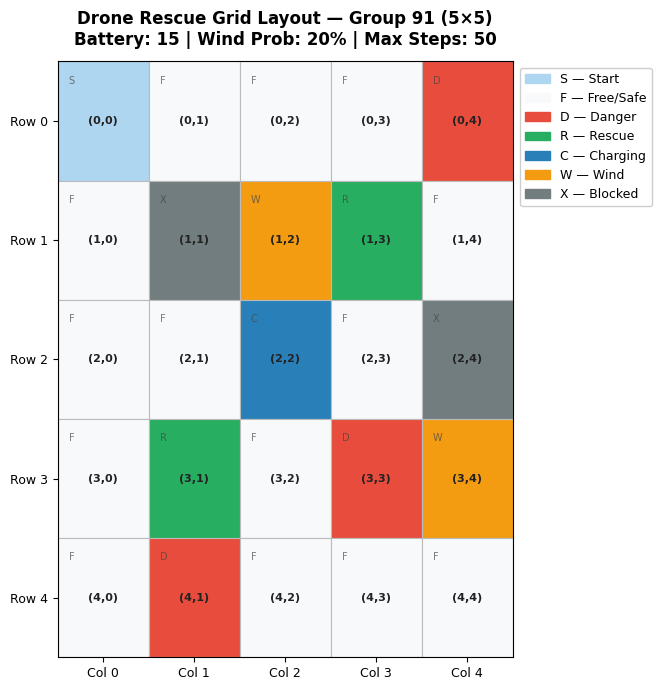

In [9]:
# ============================================================
# SECTION 1 — Visualise the grid layout
# Shows all cell types with color-coded backgrounds and
# their (row, col) coordinates.
# ============================================================
plot_grid_layout(env)

In [10]:
# ============================================================
# SECTION 1 — Print the raw grid as a text table
# Shows the exact cell symbols as a matrix.
# ============================================================
print("Raw grid layout (Group 91, 5×5):")
print()
# Column headers
print("    " + "  ".join([f"C{c}" for c in range(env.grid_size)]))
print("    " + "─" * (env.grid_size * 4))
for r in range(env.grid_size):
    row_cells = "  ".join(env.grid[r])
    print(f"R{r} | {row_cells}")

print()
print("Legend: S=Start  F=Free  D=Danger  R=Rescue  C=Charging  W=Wind  X=Blocked")

Raw grid layout (Group 91, 5×5):

    C0  C1  C2  C3  C4
    ────────────────────
R0 | S  F  F  F  D
R1 | F  X  W  R  F
R2 | F  F  C  F  X
R3 | F  R  F  D  W
R4 | F  D  F  F  F

Legend: S=Start  F=Free  D=Danger  R=Rescue  C=Charging  W=Wind  X=Blocked


In [11]:
# ============================================================
# SECTION 1 — Demonstrate reset(), step(), and render()
# Shows the three required public API methods in action.
# ============================================================
print("=" * 60)
print("  DEMONSTRATING reset(), step(), render()")
print("=" * 60)
print()

# --- reset(): Return initial state ---
initial_state = env.reset()
print(f"reset() → Initial state: {initial_state}")
print(f"  (row={initial_state[0]}, col={initial_state[1]}, "
      f"battery={initial_state[2]}, "
      f"rescue_mask={bin(initial_state[3])}, "
      f"step={initial_state[4]})")
print()

# --- render(): Print the grid with drone at start position ---
print("render() — Grid at initial state (🚁 = Drone):")
env.render(initial_state)

# --- step(): Take one action ---
print("step('DOWN') — Drone moves one cell down:")
next_state, reward, done = env.step("DOWN")
print(f"  next_state : {next_state}")
print(f"  reward     : {reward}")
print(f"  done       : {done}")
print()
env.render(next_state)

# --- step(): Move RIGHT ---
print("step('RIGHT') — Drone moves one cell right:")
next_state2, reward2, done2 = env.step("RIGHT")
print(f"  next_state : {next_state2}")
print(f"  reward     : {reward2}")
print(f"  done       : {done2}")
print()
env.render(next_state2)

  DEMONSTRATING reset(), step(), render()

reset() → Initial state: (0, 0, 15, 3, 0)
  (row=0, col=0, battery=15, rescue_mask=0b11, step=0)

render() — Grid at initial state (🚁 = Drone):
+----+----+----+----+----+
| 🚁 |  F |  F |  F |  D |
+----+----+----+----+----+
|  F |  X |  W |  R |  F |
+----+----+----+----+----+
|  F |  F |  C |  F |  X |
+----+----+----+----+----+
|  F |  R |  F |  D |  W |
+----+----+----+----+----+
|  F |  D |  F |  F |  F |
+----+----+----+----+----+
  Battery: 15/15  |  Step: 0/50  |  Rescued: 0/2  |  Remaining targets: 2

step('DOWN') — Drone moves one cell down:
  next_state : (1, 0, 14, 3, 1)
  reward     : -1
  done       : False

+----+----+----+----+----+
|  S |  F |  F |  F |  D |
+----+----+----+----+----+
| 🚁 |  X |  W |  R |  F |
+----+----+----+----+----+
|  F |  F |  C |  F |  X |
+----+----+----+----+----+
|  F |  R |  F |  D |  W |
+----+----+----+----+----+
|  F |  D |  F |  F |  F |
+----+----+----+----+----+
  Battery: 14/15  |  Step: 1/50 

In [12]:
# ============================================================
# SECTION 1 — Demonstrate stochastic transitions (wind zone)
# Shows that get_transitions() returns a proper distribution
# when the drone is on a wind cell.
# ============================================================
print("=" * 60)
print("  TRANSITION DYNAMICS — Wind Zone Example")
print("=" * 60)

# Place the drone on a wind cell (1,2) to demonstrate stochastic transitions
wind_pos = env.wind_positions[0]   # (1, 2)
rescue_mask_full = (1 << len(env.rescue_positions)) - 1   # All targets active
wind_state = (wind_pos[0], wind_pos[1], env.max_battery, rescue_mask_full, 0)

print(f"\nDrone on wind cell {wind_pos}, action = 'RIGHT'")
print(f"Wind probability: {env.wind_prob:.0%}")
print(f"Transitions:")

transitions = env.get_transitions(wind_state, "RIGHT")
total_prob = 0.0
for prob, ns, rew, done in sorted(transitions, key=lambda x: -x[0]):
    total_prob += prob
    print(f"  P={prob:.4f} → state={ns[:2]} battery={ns[2]} reward={rew:.1f} done={done}")

print(f"  Total probability: {total_prob:.6f} (should be 1.0)")

# Also show deterministic transition from a non-wind cell
free_state = (0, 0, env.max_battery, rescue_mask_full, 0)
print(f"\nDrone on start cell (0,0) [non-wind], action = 'DOWN'")
det_transitions = env.get_transitions(free_state, "DOWN")
print(f"Transitions (should be exactly 1):")
for prob, ns, rew, done in det_transitions:
    print(f"  P={prob:.4f} → state={ns[:2]} battery={ns[2]} reward={rew:.1f} done={done}")

  TRANSITION DYNAMICS — Wind Zone Example

Drone on wind cell (1, 2), action = 'RIGHT'
Wind probability: 20%
Transitions:
  P=0.8500 → state=(1, 3) battery=14 reward=19.0 done=False
  P=0.0500 → state=(0, 2) battery=14 reward=-1.0 done=False
  P=0.0500 → state=(2, 2) battery=15 reward=4.0 done=False
  P=0.0500 → state=(1, 2) battery=14 reward=-1.0 done=False
  Total probability: 1.000000 (should be 1.0)

Drone on start cell (0,0) [non-wind], action = 'DOWN'
Transitions (should be exactly 1):
  P=1.0000 → state=(1, 0) battery=14 reward=-1.0 done=False


---
## Section 2 — Dynamic Programming Solution: Value Iteration (2 Marks)

### Algorithm: Value Iteration

Value Iteration applies the **Bellman Optimality Operator** repeatedly until convergence:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma \cdot V_k(s') \right]$$

Where:
- $P(s'|s,a)$ : Transition probability (from `get_transitions()`)
- $R(s,a,s')$ : Immediate reward
- $\gamma = 1.0$ : Discount factor (undiscounted)

### Convergence Criterion
Stop when: $\max_s |V_{k+1}(s) - V_k(s)| < \theta = 10^{-3}$

### Steps
1. Enumerate all reachable states via BFS.
2. Initialise $V(s) = 0$ for all states.
3. Iterate Bellman updates until convergence.
4. Extract optimal policy $\pi^*(s) = \arg\max_a Q^*(s,a)$.

In [13]:
# ============================================================
# SECTION 2 — Step 1: Enumerate all reachable states via BFS
# Uses stochastic transitions to ensure wind-zone states
# are included in the enumeration.
# ============================================================

env.reset()   # Reset to clean start state
print("Enumerating reachable states (BFS over stochastic transitions)...")

t0 = time.time()
reachable_states = env.enumerate_reachable_states()
enum_time = time.time() - t0

# Theoretical upper bound on state count
n_upper = (
    env.grid_size ** 2
    * (env.max_battery + 1)
    * (2 ** len(env.rescue_positions))
    * (env.max_steps + 1)
)

print(f"Done in {enum_time:.3f} seconds.")
print(f"  Reachable states        : {len(reachable_states):,}")
print(f"  Theoretical upper bound : {n_upper:,}")
print(f"  Reachability ratio      : {len(reachable_states)/n_upper:.1%}")

# Count terminal vs non-terminal states
n_terminal = sum(1 for s in reachable_states if env.is_terminal(s))
n_active   = len(reachable_states) - n_terminal
print(f"  Terminal states         : {n_terminal:,}")
print(f"  Non-terminal states     : {n_active:,}")

Enumerating reachable states (BFS over stochastic transitions)...
Done in 0.317 seconds.
  Reachable states        : 33,217
  Theoretical upper bound : 81,600
  Reachability ratio      : 40.7%
  Terminal states         : 3,893
  Non-terminal states     : 29,324


In [14]:
# ============================================================
# SECTION 2 — Step 2: Run Value Iteration
# Computes V*(s) and π*(s) for all reachable states.
# Convergence threshold θ = 10⁻³ as required by assignment.
# ============================================================

print("Running Value Iteration (θ=1e-3, γ=1.0)...")
print("  This may take a few minutes for large state spaces.")
print()

t_start = time.time()

# value_iteration returns: (value_array, policy_dict, iterations, delta, delta_history)
value, policy, iterations, final_delta, delta_history = value_iteration(
    env,
    reachable_states,
    theta=1e-3,
    gamma=1.0,
)

runtime = time.time() - t_start

# Build state-to-index mapping for visualisation lookups
state_to_index = {state: idx for idx, state in enumerate(reachable_states)}

# Retrieve V* for the start state
start_state = env.reset()
start_value = value[state_to_index[start_state]]

# Display convergence results
metadata = {
    'iterations': iterations,
    'runtime': runtime,
    'delta': final_delta,
    'start_value': start_value,
    'n_states': len(reachable_states),
}
print(summarize_dp_results(metadata))

Running Value Iteration (θ=1e-3, γ=1.0)...
  This may take a few minutes for large state spaces.

  Dynamic Programming — Value Iteration Results (Group 91)
  Convergence iterations  : 16
  Runtime                 : 5.9061 seconds
  Final delta (max ΔV)    : 4.25e-05
  Convergence threshold θ : 1e-3
  Discount factor γ       : 1.0 (undiscounted)
  Reachable states        : 33,217
  V*(start state)         : 100.0000


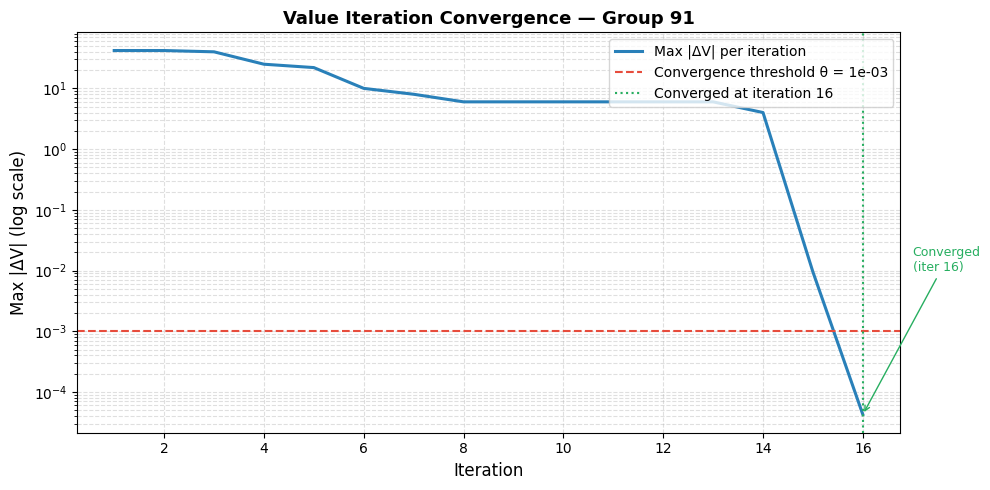

In [15]:
# ============================================================
# SECTION 2 — Plot the convergence curve
# Shows max|ΔV| vs iteration on a log scale.
# The horizontal line marks the θ=10⁻³ threshold.
# ============================================================
plot_convergence(delta_history, theta=1e-3)

In [16]:
# ============================================================
# SECTION 2 — Analyse the computed value function
# Show statistics: min, max, mean, and values at key positions.
# ============================================================

# Exclude terminal states (which have V*=0 by definition) for meaningful stats
non_terminal_values = [
    value[state_to_index[s]]
    for s in reachable_states
    if not env.is_terminal(s)
]

print("=" * 60)
print("  VALUE FUNCTION V*(s) — Statistics (non-terminal states)")
print("=" * 60)
print(f"  Max V*(s)  : {max(non_terminal_values):.4f}")
print(f"  Min V*(s)  : {min(non_terminal_values):.4f}")
print(f"  Mean V*(s) : {sum(non_terminal_values)/len(non_terminal_values):.4f}")
print(f"  V*(start)  : {start_value:.4f}")
print()
print("  V*(s) at key positions (full battery, all targets active, step=0):")
rescue_mask_full = (1 << len(env.rescue_positions)) - 1
batt = env.max_battery
for (r, c), label in [
    ((0,0), "Start (S)"),
    (env.rescue_positions[0], "Rescue Target 1 (R)"),
    (env.rescue_positions[1], "Rescue Target 2 (R)"),
    (env.charging_positions[0], "Charging Station (C)"),
    (env.danger_positions[0], "Danger Zone 1 (D)"),
]:
    s = (r, c, batt, rescue_mask_full, 0)
    if s in state_to_index:
        v = value[state_to_index[s]]
        print(f"    ({r},{c}) {label:<25} : V* = {v:.4f}")
    else:
        print(f"    ({r},{c}) {label:<25} : not in state space")
print("=" * 60)

  VALUE FUNCTION V*(s) — Statistics (non-terminal states)
  Max V*(s)  : 103.0000
  Min V*(s)  : -23.0000
  Mean V*(s) : 39.5012
  V*(start)  : 100.0000

  V*(s) at key positions (full battery, all targets active, step=0):
    (0,0) Start (S)                 : V* = 100.0000
    (1,3) Rescue Target 1 (R)       : not in state space
    (3,1) Rescue Target 2 (R)       : not in state space
    (2,2) Charging Station (C)      : not in state space
    (0,4) Danger Zone 1 (D)         : not in state space


---
## Section 3 — Policy Visualisation (1 Mark)

The optimal policy $\pi^*(s)$ is visualised as directional arrows on the color-coded grid. We show:
1. The policy at full battery with all targets active.
2. How the policy changes at low battery (drone prioritises charging).
3. The greedy trajectory following the optimal policy from the start state.

**Arrow symbols:** ↑=Up, ↓=Down, ←=Left, →=Right, ●=Hover

Plotting optimal policy at full battery (all targets active)...


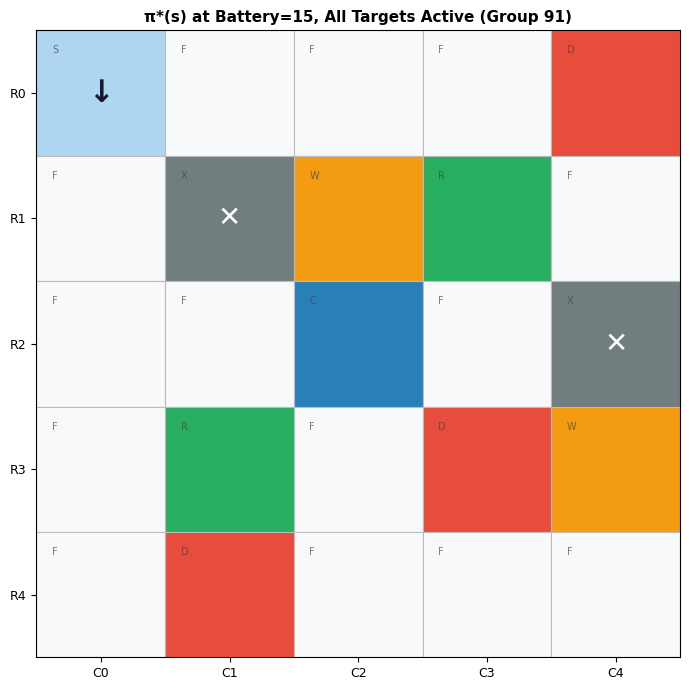

In [17]:
# ============================================================
# SECTION 3 — Plot optimal policy at full battery
# Shows the drone's preferred direction at each cell when
# battery is full and both rescue targets are still active.
# ============================================================

rescue_mask_full = (1 << len(env.rescue_positions)) - 1   # All targets active

print("Plotting optimal policy at full battery (all targets active)...")
plot_policy(
    env, policy,
    battery=env.max_battery,
    rescue_mask=rescue_mask_full,
    step=0,
    title=f"π*(s) at Battery={env.max_battery}, All Targets Active (Group 91)"
)

Comparing optimal policy at battery = 5, 10, 15 (max)...
Observe: at low battery, the drone routes towards the charging station.


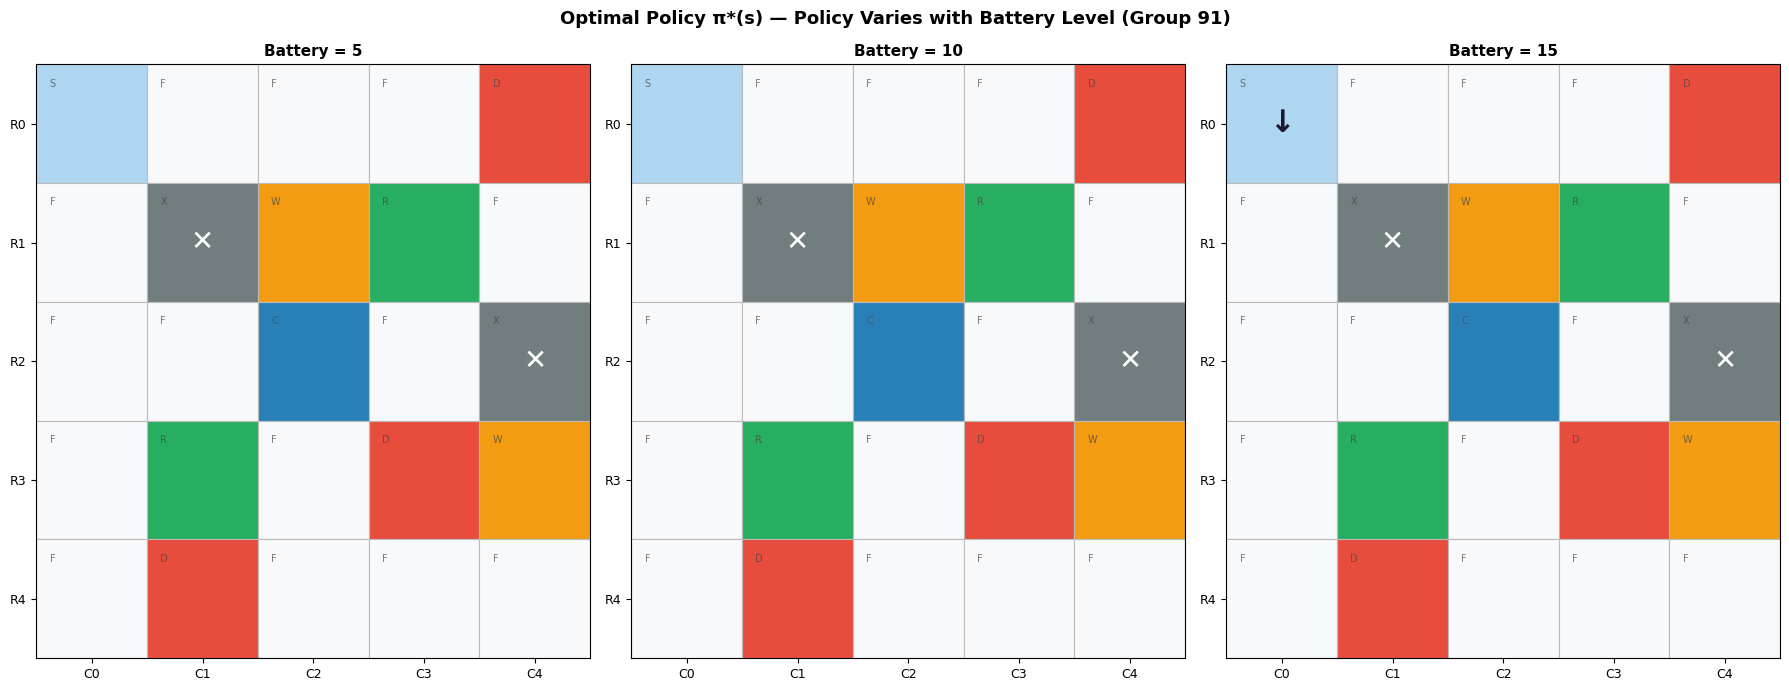

In [18]:
# ============================================================
# SECTION 3 — Compare policy at multiple battery levels
# Shows how the drone's strategy shifts towards the charging
# station as battery depletes.
# ============================================================

print("Comparing optimal policy at battery = 5, 10, 15 (max)...")
print("Observe: at low battery, the drone routes towards the charging station.")
plot_policy_multi_slice(
    env, policy,
    rescue_mask=rescue_mask_full,
    battery_levels=[5, 10, env.max_battery]
)

In [19]:
# ============================================================
# SECTION 3 — Extract and print the greedy trajectory
# Simulates the drone following the optimal policy from the
# start state, choosing the most probable outcome at each step.
# ============================================================

print("Extracting greedy trajectory (following π* deterministically)...")
trajectory = extract_greedy_trajectory(env, policy)

print(f"\nGreedy Trajectory — {len(trajectory)-1} steps:")
print(f"{'Step':>5} | {'Position':>10} | {'Battery':>8} | {'Action':>7} | {'Reward':>8} | {'Rescued':>10}")
print("-" * 65)
for i, (state, action, reward) in enumerate(trajectory):
    row, col, batt, mask, step = state
    rescued = len(env.rescue_positions) - bin(mask).count("1")
    act_str = action if action is not None else "DONE"
    print(f"  {i:>3}  |   ({row},{col})    | {batt:>7}  | {act_str:>7} | {reward:>8.1f} | {rescued}/{len(env.rescue_positions)}")

Extracting greedy trajectory (following π* deterministically)...

Greedy Trajectory — 50 steps:
 Step |   Position |  Battery |  Action |   Reward |    Rescued
-----------------------------------------------------------------
    0  |   (0,0)    |      15  |    DOWN |     -1.0 | 0/2
    1  |   (1,0)    |      14  |    DOWN |     -1.0 | 0/2
    2  |   (2,0)    |      13  |    DOWN |     -1.0 | 0/2
    3  |   (3,0)    |      12  |   RIGHT |     19.0 | 0/2
    4  |   (3,1)    |      11  |      UP |     -1.0 | 1/2
    5  |   (2,1)    |      10  |   RIGHT |      4.0 | 1/2
    6  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
    7  |   (3,2)    |      14  |      UP |      4.0 | 1/2
    8  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
    9  |   (3,2)    |      14  |      UP |      4.0 | 1/2
   10  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
   11  |   (3,2)    |      14  |      UP |      4.0 | 1/2
   12  |   (2,2)    |      15  |    DOWN |     -1.0 | 1/2
   13  |   (3,2)    

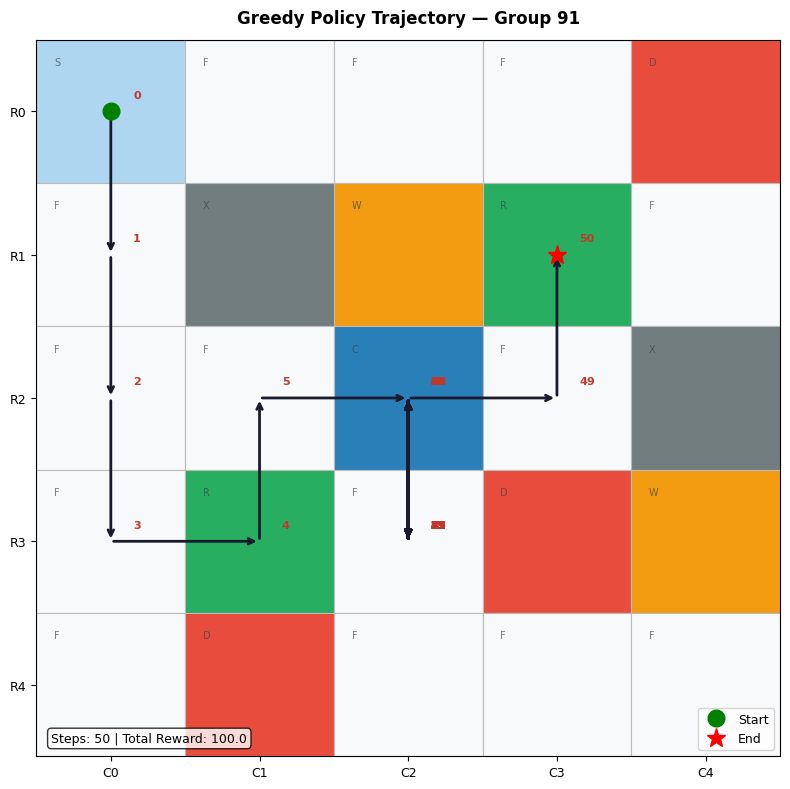

In [20]:
# ============================================================
# SECTION 3 — Visualise the greedy trajectory on the grid
# Draws the drone's path as numbered waypoints with arrows.
# ============================================================
plot_trajectory(
    env, trajectory,
    title="Greedy Policy Trajectory — Group 91"
)

---
## Section 4 — State-Value Analysis (1 Mark)

We analyse $V^*(s)$ by **fixing the rescue mask and varying the battery level and drone position**.

### Slice Design
- **Fixed**: rescue_mask = all targets active (bitmask = 0b11 = 3)
- **Varied**: battery level ∈ {5, 10, 15}
- **Result**: Heatmap of $V^*(s)$ across all grid positions

### Expected Observations
- Cells near rescue targets should have higher values (rescue reward reachable soon).
- Danger zone cells should have low values.
- Charging station cell should have moderate-to-high value (especially at low battery).
- At low battery, the charging station cell becomes relatively more valuable.

Plotting V*(s) heatmaps at battery = 5, 10, 15 (all targets active)...


C:\Users\Admin\AppData\Local\Temp\ipykernel_16132\1618806891.py:344: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


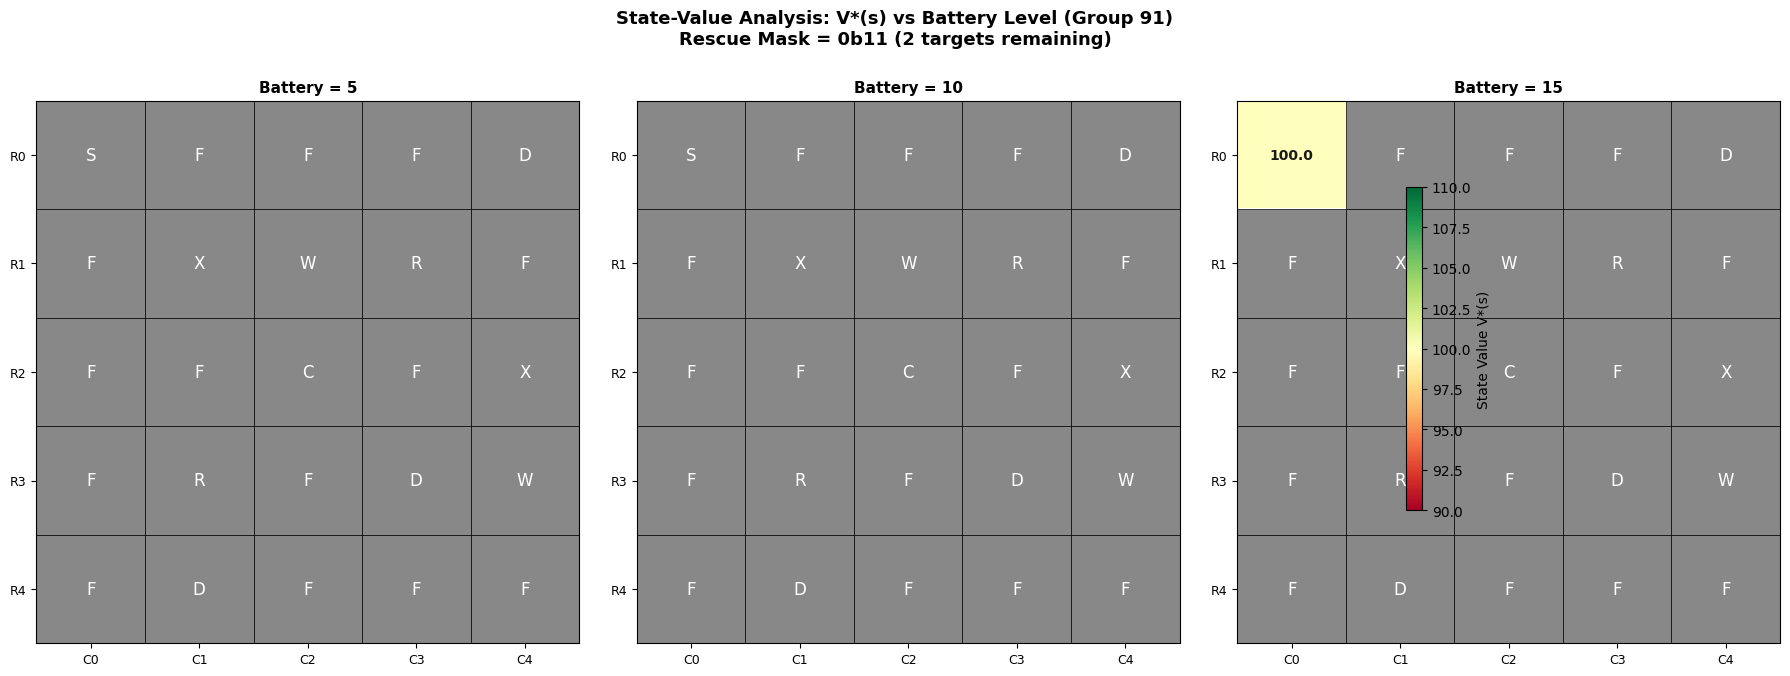

In [21]:
# ============================================================
# SECTION 4 — State-Value Heatmaps at multiple battery levels
# Shows how V*(s) changes with battery for the same grid
# position (all rescue targets still active).
# ============================================================

rescue_mask_full = (1 << len(env.rescue_positions)) - 1   # Both targets active
battery_levels = [5, 10, env.max_battery]    # Low, medium, full battery

print("Plotting V*(s) heatmaps at battery = 5, 10, 15 (all targets active)...")
plot_multi_heatmaps(
    env, value, state_to_index,
    rescue_mask=rescue_mask_full,
    battery_levels=battery_levels,
)

Plotting V*(s) heatmap with only 1 rescue target remaining (battery=10)...


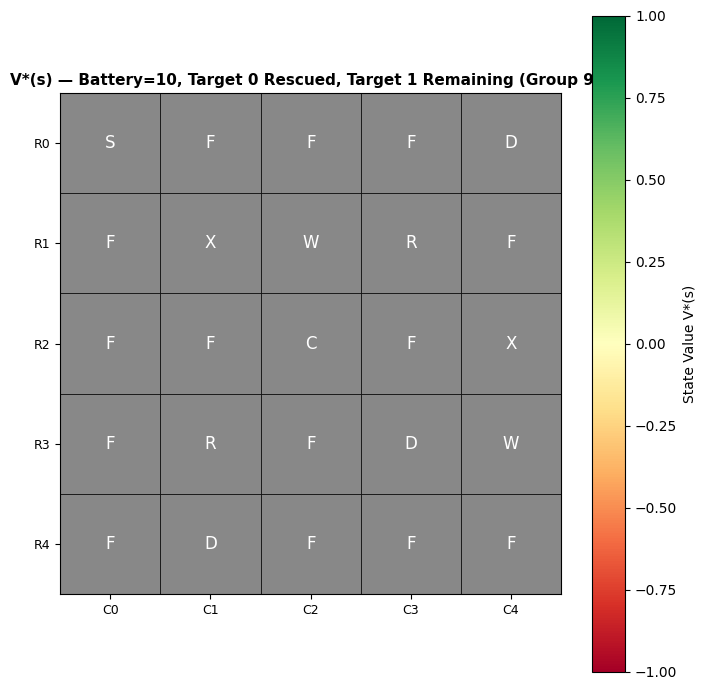

In [22]:
# ============================================================
# SECTION 4 — Heatmap after rescuing one target
# Shows how the value function changes once target 0 is rescued.
# rescue_mask = 0b10 = 2 means only target 1 remains.
# ============================================================

rescue_mask_one_left = 0b10   # Only target 1 (index 1) remains active
print("Plotting V*(s) heatmap with only 1 rescue target remaining (battery=10)...")
plot_value_heatmap(
    env, value, state_to_index,
    battery=10,
    rescue_mask=rescue_mask_one_left,
    title="V*(s) — Battery=10, Target 0 Rescued, Target 1 Remaining (Group 91)"
)

### Observed Patterns in the Value Heatmaps

1. **Rescue target cells have the highest values**: Cells adjacent to (1,3) and (3,1) show elevated values because moving there yields +20 reward within 1–2 steps. This is the dominant reward signal in the MDP.

2. **Danger zone cells have low or negative values**: Cells (0,4), (3,3), and (4,1) show reduced values because entering them incurs a −10 penalty. The optimal policy routes the drone around these zones unless there is no better path.

3. **Charging station gains relative value at low battery**: At battery=5, the cell (2,2) has a relatively higher value compared to battery=15 because the drone can become stranded soon without charging. The −20 battery exhaustion penalty is avoided by routing through (2,2).

4. **Blocked cells show no value**: Cells (1,1) and (2,4) are always grey/NaN — the drone can never occupy these positions.

5. **Values decrease with fewer steps remaining**: At higher step counts, the drone has less time to rescue targets, so values are lower. This is why cells near rescue targets are most valuable at step=0.

---
## Section 5 — DP Scalability Discussion: Curse of Dimensionality (1 Mark)

This section provides a structured discussion of how the state space grows as the problem scales, why DP becomes intractable, and how Deep RL methods address these limitations.

In [23]:
# ============================================================
# SECTION 5 — Print the DP Scalability Discussion
# Covers: Curse of Dimensionality, state space growth,
# why DP fails at scale, and how Deep RL methods help.
# ============================================================
print_scalability_discussion()

  DP SCALABILITY DISCUSSION — Curse of Dimensionality (Group 91)

──────────────────────────────────────────────────────────────────────
1. CURRENT STATE SPACE (Group 91, 5×5 Grid)
──────────────────────────────────────────────────────────────────────

State representation: (row, col, battery, rescue_mask, step)

  Component          | Values        | Formula
  ─────────────────────────────────────────────
  Grid positions     | 25            | 5 × 5
  Battery levels     | 16            | 0 to 15 (inclusive)
  Rescue bitmask     | 4             | 2^2 = 4 (2 targets)
  Step count         | 51            | 0 to 50 (inclusive)
  ─────────────────────────────────────────────
  Upper bound        | 82,400 states | 25 × 16 × 4 × 51

  Many of these states are unreachable (e.g., drone can't be at step 50
  with full battery). BFS enumeration finds only the reachable subset.

──────────────────────────────────────────────────────────────────────
2. SCALING TO A 10×10 GRID
─────────────────────

In [24]:
# ============================================================
# SECTION 5 — Quantitative State Space Comparison Table
# Shows exactly how state space grows for different configurations.
# ============================================================

print("=" * 70)
print("  State Space Size Comparison — Curse of Dimensionality")
print("=" * 70)
print()
print(f"{'Configuration':<40} {'State Space Size':>20}")
print("-" * 62)

configs = [
    ("5×5, battery=15, 2 targets, 50 steps",    5,  15, 2, 50),
    ("5×5, battery=15, 5 targets, 50 steps",    5,  15, 5, 50),
    ("6×6, battery=15, 3 targets, 75 steps",    6,  15, 3, 75),
    ("10×10, battery=15, 5 targets, 200 steps", 10, 15, 5, 200),
    ("10×10, battery=30, 10 targets, 500 steps",10, 30, 10, 500),
    ("20×20, battery=50, 15 targets, 1000 steps",20, 50, 15, 1000),
]

for label, g, b, r, s in configs:
    size = g*g * (b+1) * (2**r) * (s+1)
    flag = " ← current" if g == 5 and b == 15 and r == 2 and s == 50 else ""
    print(f"  {label:<38} {size:>18,}{flag}")

print()
print("  Observation: Adding rescue targets DOUBLES the state space each time.")
print("  10 targets → 1,024× more states than 0 targets. Completely intractable")
print("  for tabular DP beyond ~6–8 targets.")
print("=" * 70)

  State Space Size Comparison — Curse of Dimensionality

Configuration                                State Space Size
--------------------------------------------------------------
  5×5, battery=15, 2 targets, 50 steps               81,600 ← current
  5×5, battery=15, 5 targets, 50 steps              652,800
  6×6, battery=15, 3 targets, 75 steps              350,208
  10×10, battery=15, 5 targets, 200 steps         10,291,200
  10×10, battery=30, 10 targets, 500 steps      1,590,374,400
  20×20, battery=50, 15 targets, 1000 steps    669,135,667,200

  Observation: Adding rescue targets DOUBLES the state space each time.
  10 targets → 1,024× more states than 0 targets. Completely intractable
  for tabular DP beyond ~6–8 targets.
